[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aangelopoulos/conformal-prediction/blob/main/notebooks/imagenet-aps.ipynb)

In [14]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

!pip install -U --no-cache-dir gdown --pre

## [Click this link](https://github.com/aangelopoulos/conformal-prediction/blob/main/notebooks/imagenet-raps.ipynb) for a version of APS with much-improved practical performance.

In [15]:
# Load cached data
if not os.path.exists("../data"):
    os.system("gdown 1h7S6N_Rx7gdfO3ZunzErZy6H7620EbZK -O ../data.tar.gz")
    os.system("tar -xf ../data.tar.gz -C ../")
    os.system("rm ../data.tar.gz")
if not os.path.exists("../data/imagenet/human_readable_labels.json"):
    !wget -nv -O ../data/imagenet/human_readable_labels.json -L https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json

data = np.load("../data/imagenet/imagenet-resnet152.npz")
example_paths = os.listdir("../data/imagenet/examples")
smx = data["smx"]
labels = data["labels"].astype(int)

In [16]:
# Problem setup
n = 1000  # number of calibration points
alpha = 0.1  # 1-alpha is the desired coverage

In [17]:
# Split the softmax scores into calibration and validation sets (save the shuffling)
idx = np.array([1] * n + [0] * (smx.shape[0] - n)) > 0
np.random.shuffle(idx)
cal_smx, val_smx = smx[idx, :], smx[~idx, :]
cal_labels, val_labels = labels[idx], labels[~idx]

### Conformal prediction happens here

In [18]:
# Get scores. calib_X.shape[0] == calib_Y.shape[0] == n
cal_pi = cal_smx.argsort(1)[:, ::-1]    # same as π(x): sorts the class indices for each calibration image from highest probability to lowest probability..
cal_srt = np.take_along_axis(cal_smx, cal_pi, axis=1).cumsum(axis=1) # first sort the probability accroding to cal_pi (indices), then make cumalative sum from from top class downward
cal_scores = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)[
    range(n), cal_labels
]     # the cumulative probability mass up to the true class for image i
# Suppose one image has class probabilities:
# class 0: 0.2
# class 1: 0.7
# class 2: 0.1
# True label is class 0.
# Sorted descending: [0.7, 0.2, 0.1]
# Cumulative sum: [0.7, 0.9, 1.0]
# True class 0 is in position 2nd in sorted list, so cumulative score is: 0.9

# Get the score quantile
qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher"
)   # get the q^ value based on alpha= 0.1, i.e., 90%

# Deploy (output=list of length n, each element is tensor of classes)
val_pi = val_smx.argsort(1)[:, ::-1]    # For each validation image, sort class indices from highest to lowest probability.
val_srt = np.take_along_axis(val_smx, val_pi, axis=1).cumsum(axis=1)    # # first sort the probability accroding to val_pi (indices), then make cumalative sum from from top class downward
prediction_sets = np.take_along_axis(val_srt <= qhat, val_pi.argsort(axis=1), axis=1)

# For each validation image and each sorted position, check:
# is cumulative probability (val_srt) still ≤ qhat?
# If yes → include
# If no → stop including
# So this creates a Boolean mask in sorted order.
# If: sorted probabilities = [0.4, 0.3, 0.2, 0.1]
# cumulative = [0.4, 0.7, 0.9, 1.0]
# qhat = 0.85
# then: val_srt <= qhat → [True, True, False, False]
# So we include the first two classes to make prediciton set


In [19]:
# Calculate empirical coverage: For each validation image check whether it is included in the prediction set
empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), val_labels
].mean()
print(f"The empirical coverage is: {empirical_coverage}")

The empirical coverage is: 0.9028979591836734


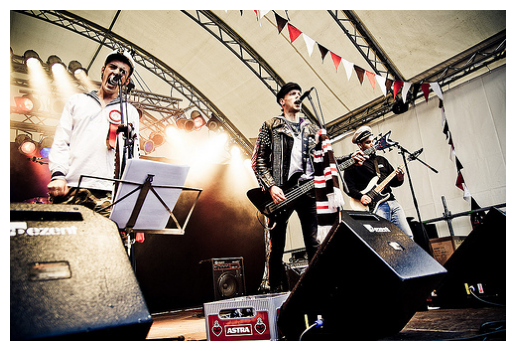

The prediction set is: [np.str_('great white shark'), np.str_('cock'), np.str_('Gila monster'), np.str_('American alligator'), np.str_('triceratops'), np.str_('Indian cobra'), np.str_('grey parrot'), np.str_('sea lion'), np.str_('Kerry Blue Terrier'), np.str_('Dalmatian'), np.str_('Miniature Poodle'), np.str_('Standard Poodle'), np.str_('European polecat'), np.str_('gorilla'), np.str_('chimpanzee'), np.str_('coho salmon'), np.str_('abacus'), np.str_('abaya'), np.str_('accordion'), np.str_('acoustic guitar'), np.str_('aircraft carrier'), np.str_('altar'), np.str_('analog clock'), np.str_('apron'), np.str_('waste container'), np.str_('assault rifle'), np.str_('backpack'), np.str_('bakery'), np.str_('balance beam'), np.str_('balloon'), np.str_('ballpoint pen'), np.str_('banjo'), np.str_('baluster'), np.str_('barbell'), np.str_('barber chair'), np.str_('barbershop'), np.str_('barrel'), np.str_('wheelbarrow'), np.str_('baseball'), np.str_('basketball'), np.str_('bassoon'), np.str_('bathtub'

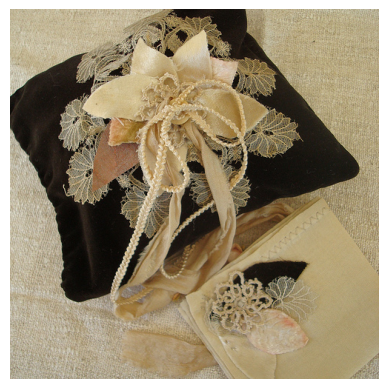

The prediction set is: [np.str_('goldfish'), np.str_('great white shark'), np.str_('hammerhead shark'), np.str_('electric ray'), np.str_('stingray'), np.str_('vulture'), np.str_('loggerhead sea turtle'), np.str_('leatherback sea turtle'), np.str_('triceratops'), np.str_('sea snake'), np.str_('trilobite'), np.str_('harvestman'), np.str_('yellow garden spider'), np.str_('barn spider'), np.str_('European garden spider'), np.str_('southern black widow'), np.str_('tarantula'), np.str_('wolf spider'), np.str_('tick'), np.str_('centipede'), np.str_('peacock'), np.str_('jellyfish'), np.str_('sea anemone'), np.str_('brain coral'), np.str_('nematode'), np.str_('conch'), np.str_('sea slug'), np.str_('chiton'), np.str_('chambered nautilus'), np.str_('Dungeness crab'), np.str_('rock crab'), np.str_('fiddler crab'), np.str_('red king crab'), np.str_('spiny lobster'), np.str_('crayfish'), np.str_('hermit crab'), np.str_('isopod'), np.str_('American coot'), np.str_('bustard'), np.str_('oystercatcher')

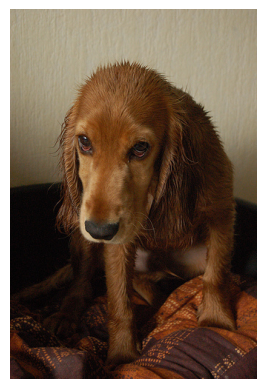

The prediction set is: [np.str_('jay'), np.str_('box turtle'), np.str_('agama'), np.str_('frilled-necked lizard'), np.str_('European green lizard'), np.str_('smooth green snake'), np.str_('vine snake'), np.str_('African rock python'), np.str_('green mamba'), np.str_('eastern diamondback rattlesnake'), np.str_('barn spider'), np.str_('European garden spider'), np.str_('tarantula'), np.str_('wolf spider'), np.str_('tick'), np.str_('macaw'), np.str_('toucan'), np.str_('duck'), np.str_('jellyfish'), np.str_('conch'), np.str_('chambered nautilus'), np.str_('red king crab'), np.str_('American lobster'), np.str_('spiny lobster'), np.str_('crayfish'), np.str_('hermit crab'), np.str_('isopod'), np.str_('bittern'), np.str_('Chihuahua'), np.str_('Japanese Chin'), np.str_('Pekingese'), np.str_('King Charles Spaniel'), np.str_('toy terrier'), np.str_('Rhodesian Ridgeback'), np.str_('Afghan Hound'), np.str_('Basset Hound'), np.str_('Beagle'), np.str_('Bloodhound'), np.str_('Bluetick Coonhound'), np.

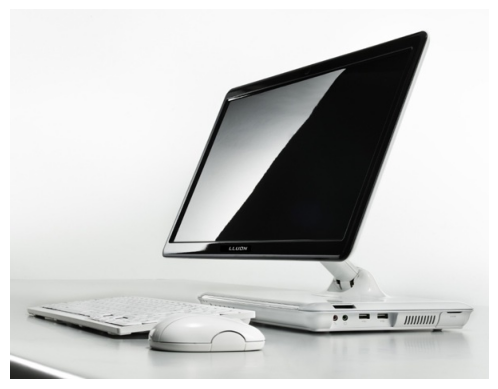

The prediction set is: [np.str_('house finch'), np.str_('jay'), np.str_('magpie'), np.str_('kite'), np.str_('great grey owl'), np.str_('vine snake'), np.str_('night snake'), np.str_('harvestman'), np.str_('tick'), np.str_('grey parrot'), np.str_('hummingbird'), np.str_('snail'), np.str_('slug'), np.str_('albatross'), np.str_('Rhodesian Ridgeback'), np.str_('Bloodhound'), np.str_('Bluetick Coonhound'), np.str_('Redbone Coonhound'), np.str_('Norwegian Elkhound'), np.str_('Norfolk Terrier'), np.str_('Norwich Terrier'), np.str_('Airedale Terrier'), np.str_('Vizsla'), np.str_('Kuvasz'), np.str_('Schipperke'), np.str_('collie'), np.str_('German Shepherd Dog'), np.str_('husky'), np.str_('Alaskan Malamute'), np.str_('Dalmatian'), np.str_('Basenji'), np.str_('pug'), np.str_('Newfoundland'), np.str_('Samoyed'), np.str_('Pomeranian'), np.str_('Pembroke Welsh Corgi'), np.str_('Cardigan Welsh Corgi'), np.str_('Toy Poodle'), np.str_('tabby cat'), np.str_('tiger cat'), np.str_('Persian cat'), np.str_

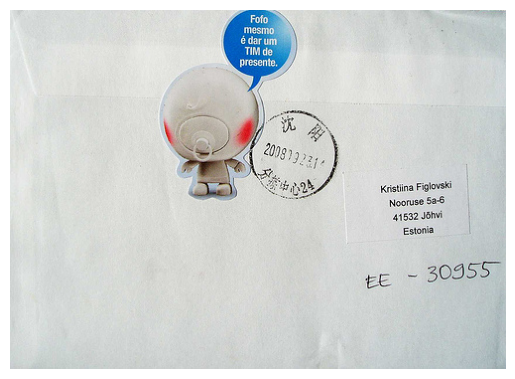

The prediction set is: [np.str_('tick'), np.str_('abacus'), np.str_('analog clock'), np.str_('apron'), np.str_('backpack'), np.str_('balloon'), np.str_('ballpoint pen'), np.str_('barometer'), np.str_('bathtub'), np.str_('bib'), np.str_('ring binder'), np.str_('poke bonnet'), np.str_('bottle cap'), np.str_('bucket'), np.str_('can opener'), np.str_('carton'), np.str_('cassette'), np.str_('chain'), np.str_('combination lock'), np.str_('infant bed'), np.str_('diaper'), np.str_('digital watch'), np.str_('dishwasher'), np.str_('electric fan'), np.str_('envelope'), np.str_('fountain pen'), np.str_('barrette'), np.str_('handkerchief'), np.str_('hook'), np.str_('iPod'), np.str_('clothes iron'), np.str_('T-shirt'), np.str_('knot'), np.str_('lab coat'), np.str_('lens cap'), np.str_('paper knife'), np.str_('loupe'), np.str_('magnetic compass'), np.str_('mail bag'), np.str_('mailbox'), np.str_('measuring cup'), np.str_('necklace'), np.str_('nipple'), np.str_('packet'), np.str_('padlock'), np.str_('

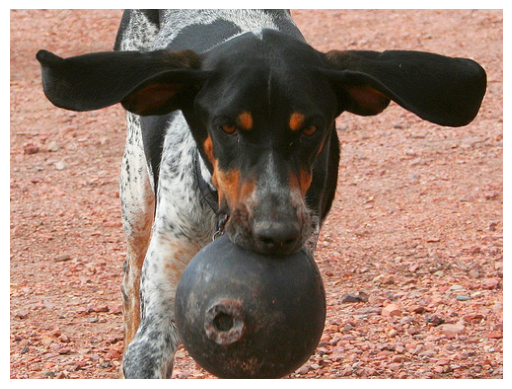

The prediction set is: [np.str_('great white shark'), np.str_('cock'), np.str_('hen'), np.str_('junco'), np.str_('American robin'), np.str_('jay'), np.str_('magpie'), np.str_('American dipper'), np.str_('great grey owl'), np.str_('spotted salamander'), np.str_('American bullfrog'), np.str_('tree frog'), np.str_('tailed frog'), np.str_('loggerhead sea turtle'), np.str_('leatherback sea turtle'), np.str_('mud turtle'), np.str_('terrapin'), np.str_('box turtle'), np.str_('green iguana'), np.str_('desert grassland whiptail lizard'), np.str_('agama'), np.str_('frilled-necked lizard'), np.str_('Nile crocodile'), np.str_('triceratops'), np.str_('ring-necked snake'), np.str_('eastern hog-nosed snake'), np.str_('smooth green snake'), np.str_('kingsnake'), np.str_('garter snake'), np.str_('night snake'), np.str_('African rock python'), np.str_('green mamba'), np.str_('Saharan horned viper'), np.str_('yellow garden spider'), np.str_('barn spider'), np.str_('southern black widow'), np.str_('tarant

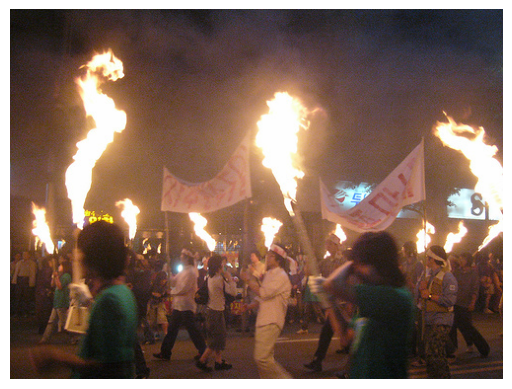

The prediction set is: [np.str_('torch'), np.str_('volcano')]


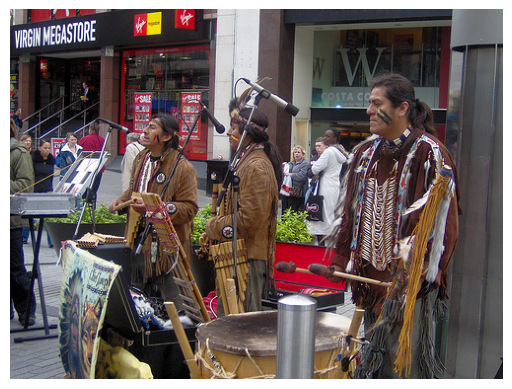

The prediction set is: [np.str_('Indian cobra'), np.str_('tusker'), np.str_('red king crab'), np.str_('Asian elephant'), np.str_('accordion'), np.str_('bakery'), np.str_('banjo'), np.str_('barrel'), np.str_('bassoon'), np.str_('military cap'), np.str_('bookstore'), np.str_('bow'), np.str_('breastplate'), np.str_('broom'), np.str_('bucket'), np.str_('butcher shop'), np.str_('cauldron'), np.str_('cello'), np.str_('chain mail'), np.str_('chainsaw'), np.str_('chime'), np.str_('clogs'), np.str_('confectionery store'), np.str_('cornet'), np.str_('cowboy hat'), np.str_('crutch'), np.str_('cuirass'), np.str_('drum'), np.str_('drumstick'), np.str_('flute'), np.str_('forklift'), np.str_('French horn'), np.str_('fur coat'), np.str_('gong'), np.str_('grocery store'), np.str_('hammer'), np.str_('harmonica'), np.str_('harp'), np.str_('hatchet'), np.str_('holster'), np.str_('horse-drawn vehicle'), np.str_('pulled rickshaw'), np.str_('ladle'), np.str_('sawmill'), np.str_('maraca'), np.str_('marimba'),

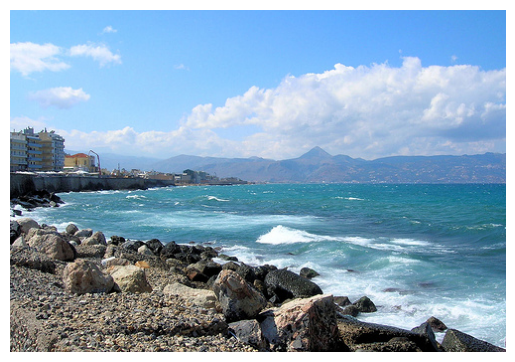

The prediction set is: [np.str_('great white shark'), np.str_('hammerhead shark'), np.str_('stingray'), np.str_('magpie'), np.str_('American dipper'), np.str_('bald eagle'), np.str_('vulture'), np.str_('loggerhead sea turtle'), np.str_('leatherback sea turtle'), np.str_('green iguana'), np.str_('agama'), np.str_('boa constrictor'), np.str_('sea snake'), np.str_('trilobite'), np.str_('scorpion'), np.str_('tarantula'), np.str_('wolf spider'), np.str_('ptarmigan'), np.str_('peacock'), np.str_('quail'), np.str_('bee eater'), np.str_('hummingbird'), np.str_('red-breasted merganser'), np.str_('goose'), np.str_('black swan'), np.str_('jellyfish'), np.str_('sea anemone'), np.str_('brain coral'), np.str_('conch'), np.str_('chiton'), np.str_('Dungeness crab'), np.str_('rock crab'), np.str_('crayfish'), np.str_('hermit crab'), np.str_('black stork'), np.str_('great egret'), np.str_('ruddy turnstone'), np.str_('dunlin'), np.str_('common redshank'), np.str_('oystercatcher'), np.str_('pelican'), np.

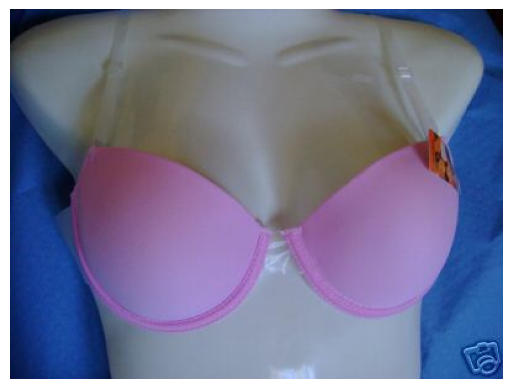

The prediction set is: [np.str_('tench'), np.str_('goldfish'), np.str_('hammerhead shark'), np.str_('electric ray'), np.str_('stingray'), np.str_('goldfinch'), np.str_('chickadee'), np.str_('vulture'), np.str_('axolotl'), np.str_('American bullfrog'), np.str_('tailed frog'), np.str_('loggerhead sea turtle'), np.str_('leatherback sea turtle'), np.str_('mud turtle'), np.str_('terrapin'), np.str_('banded gecko'), np.str_('desert grassland whiptail lizard'), np.str_('European green lizard'), np.str_('chameleon'), np.str_('ring-necked snake'), np.str_('smooth green snake'), np.str_('water snake'), np.str_('vine snake'), np.str_('night snake'), np.str_('trilobite'), np.str_('scorpion'), np.str_('European garden spider'), np.str_('southern black widow'), np.str_('centipede'), np.str_('prairie grouse'), np.str_('partridge'), np.str_('grey parrot'), np.str_('macaw'), np.str_('bee eater'), np.str_('hummingbird'), np.str_('jacamar'), np.str_('toucan'), np.str_('duck'), np.str_('red-breasted merga

In [21]:
# Show some examples
with open("../data/imagenet/human_readable_labels.json") as f:
    label_strings = np.array(json.load(f))

example_paths = os.listdir("../data/imagenet/examples")
for i in range(10):
    rand_path = np.random.choice(example_paths)
    img = imread("../data/imagenet/examples/" + rand_path)
    img_index = int(rand_path.split(".")[0])
    img_pi = smx[img_index].argsort()[::-1]
    img_srt = np.take_along_axis(smx[img_index], img_pi, axis=0).cumsum()
    prediction_set = np.take_along_axis(img_srt <= qhat, img_pi.argsort(), axis=0)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.show()
    print(f"The prediction set is: {list(label_strings[prediction_set])}")

This method was first introduced in https://arxiv.org/abs/2006.02544 and studied further for image classifiers in https://arxiv.org/abs/2009.14193.